In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [214]:
df = pd.read_csv("energy2.csv")

In [215]:
df.head()

,time,students,temperature,appliances,humidity,day_of_week,is_weekend,num_classes,random_noise,building_color_code,id_number,energy
0,6,213,35.14,19,20.84,3,0,7,-0.90,263.75,1.69,916.27
1,19,256,21.94,15,25.98,2,0,2,0.06,316.65,1.82,917.74
2,14,493,19.54,12,34.61,2,0,7,1.59,369.02,2.07,1372.60
3,10,222,33.73,30,21.79,3,0,5,-0.30,730.78,4.61,1018.39
4,7,211,35.18,49,32.92,4,0,5,1.31,946.48,5.49,1301.57


In [216]:
df = df.drop_duplicates()

In [217]:
n = df.isnull().sum().sum()
if n<=50:
    df = df.dropna()
else:
    df.fillna(df.mode().iloc[0], inplace=True)

In [218]:
df["time_sin"] = np.sin(2 * np.pi * df["time"] / 24)
df["time_cos"] = np.cos(2 * np.pi * df["time"] / 24)
df.head()

,time,students,temperature,appliances,humidity,day_of_week,is_weekend,num_classes,random_noise,building_color_code,id_number,energy,time_sin,time_cos
0,6,213,35.14,19,20.84,3,0,7,-0.90,263.75,1.69,916.27,1.000000,6.123234e-17
1,19,256,21.94,15,25.98,2,0,2,0.06,316.65,1.82,917.74,-0.965926,2.588190e-01
2,14,493,19.54,12,34.61,2,0,7,1.59,369.02,2.07,1372.60,-0.500000,-8.660254e-01
3,10,222,33.73,30,21.79,3,0,5,-0.30,730.78,4.61,1018.39,0.500000,-8.660254e-01
4,7,211,35.18,49,32.92,4,0,5,1.31,946.48,5.49,1301.57,0.965926,-2.588190e-01


In [219]:
df = df.drop(columns = ["building_color_code", "id_number", "time"] , axis = 1)
df.head()

,students,temperature,appliances,humidity,day_of_week,is_weekend,num_classes,random_noise,energy,time_sin,time_cos
0,213,35.14,19,20.84,3,0,7,-0.90,916.27,1.000000,6.123234e-17
1,256,21.94,15,25.98,2,0,2,0.06,917.74,-0.965926,2.588190e-01
2,493,19.54,12,34.61,2,0,7,1.59,1372.60,-0.500000,-8.660254e-01
3,222,33.73,30,21.79,3,0,5,-0.30,1018.39,0.500000,-8.660254e-01
4,211,35.18,49,32.92,4,0,5,1.31,1301.57,0.965926,-2.588190e-01


In [220]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\nCategorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)


Categorical Columns: Index([], dtype='object')
Numerical Columns: Index(['students', 'temperature', 'appliances', 'humidity', 'day_of_week',
       'is_weekend', 'num_classes', 'random_noise', 'energy', 'time_sin',
       'time_cos'],
      dtype='object')


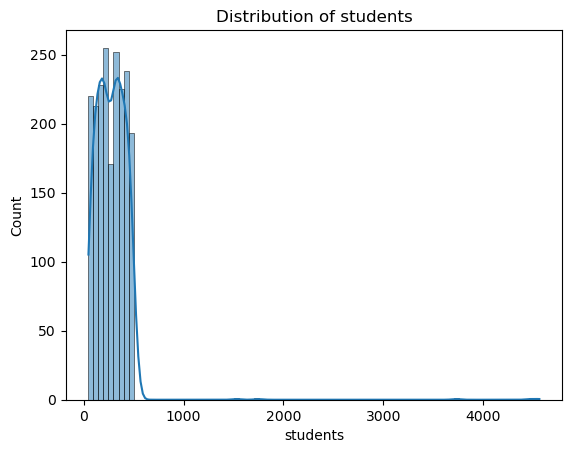

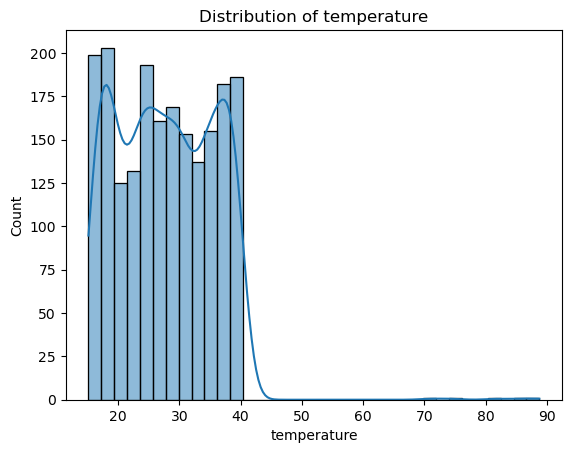

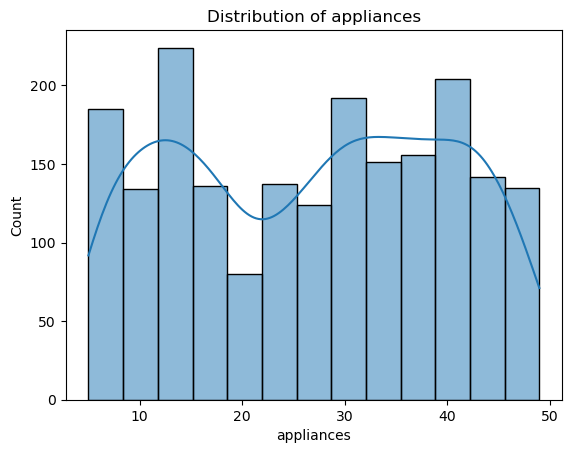

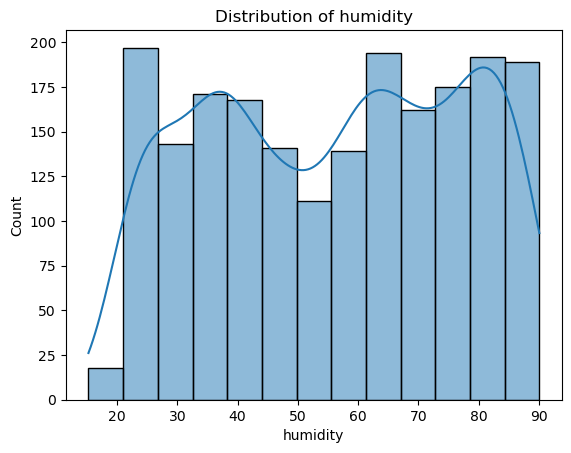

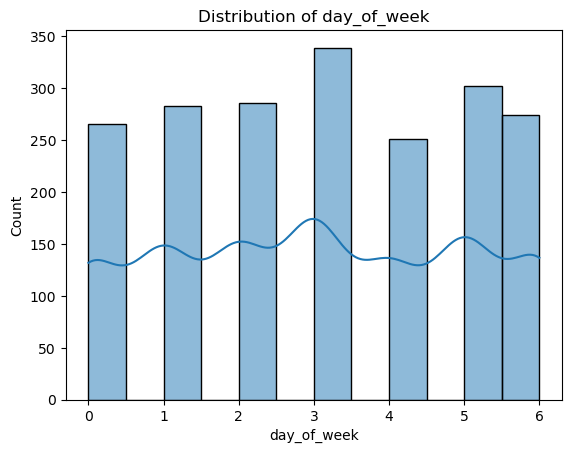

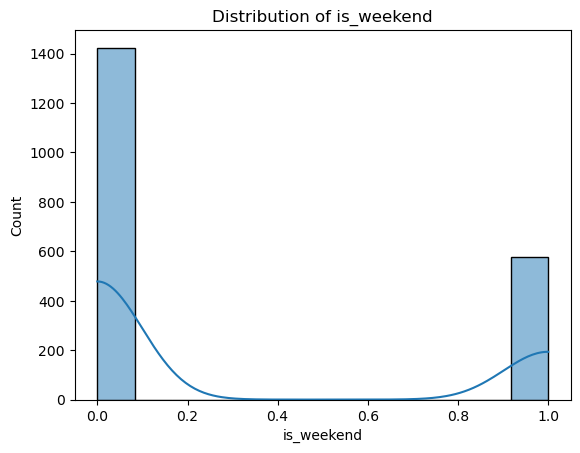

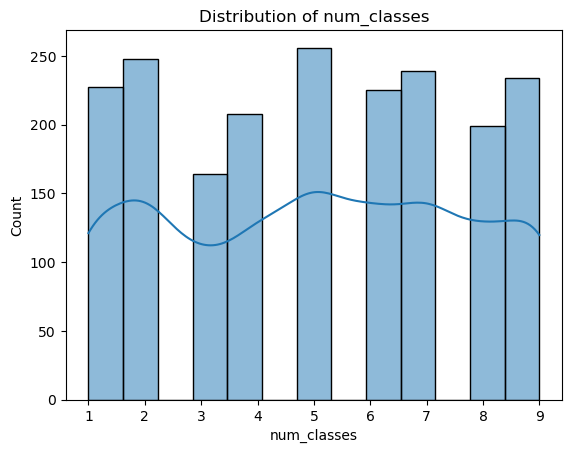

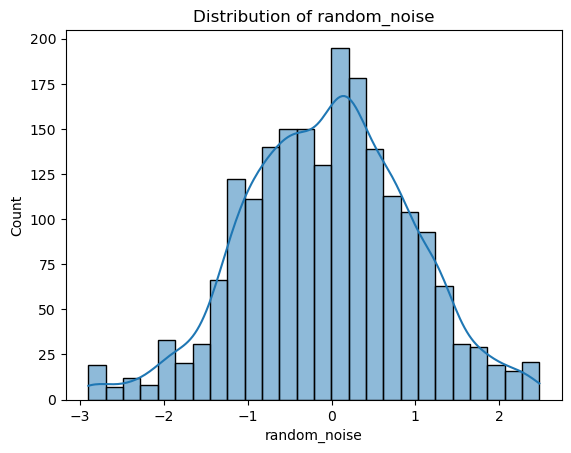

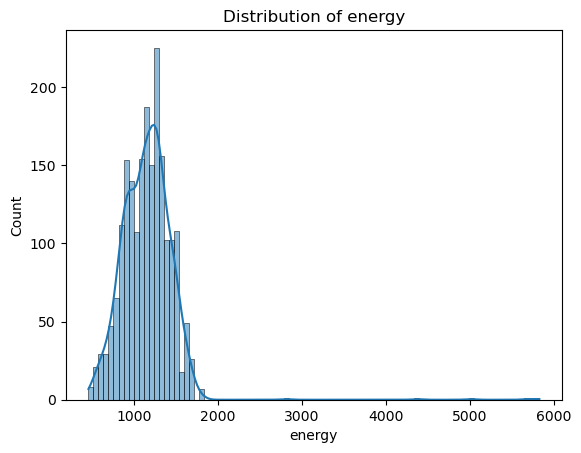

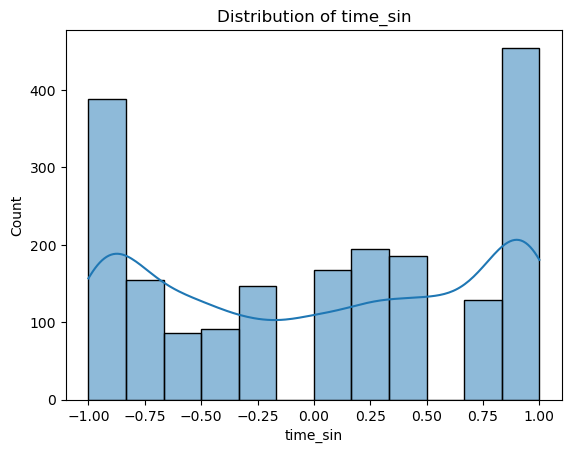

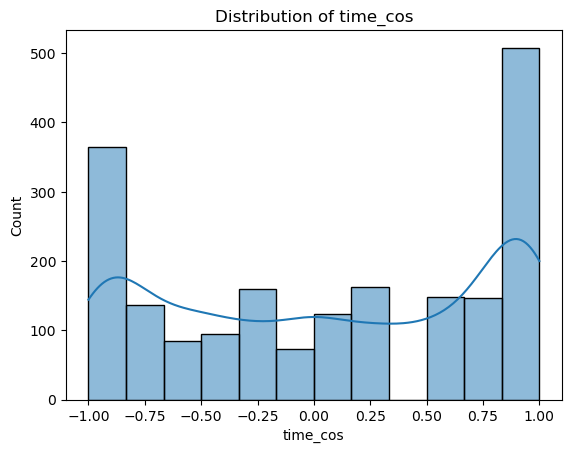

In [221]:
#Univariate Analysis
#checking for the distribution of variable
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

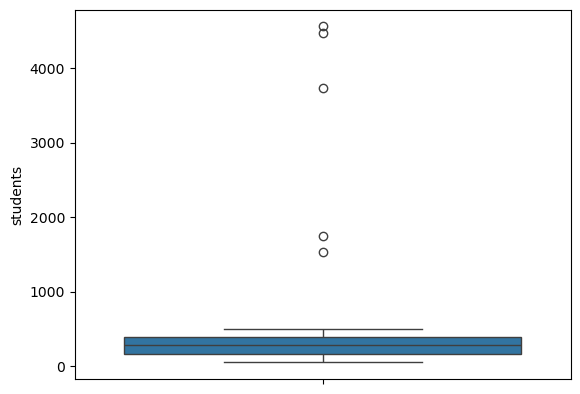

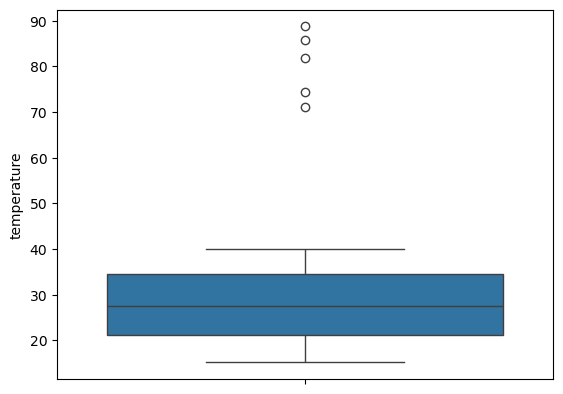

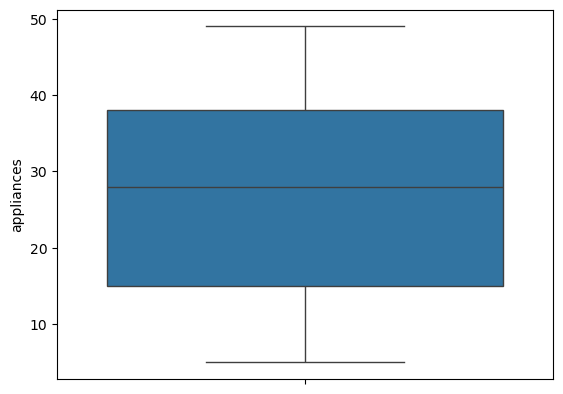

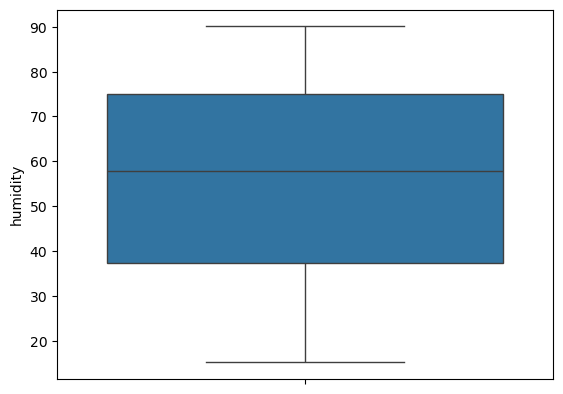

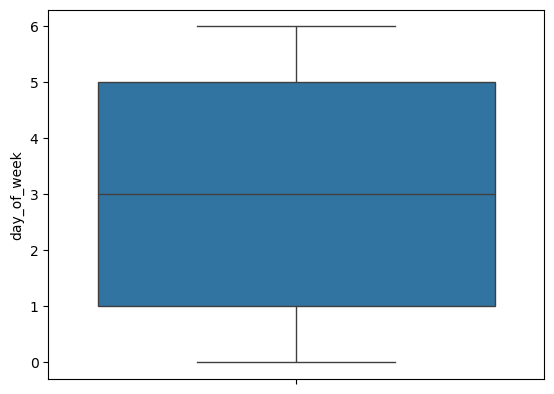

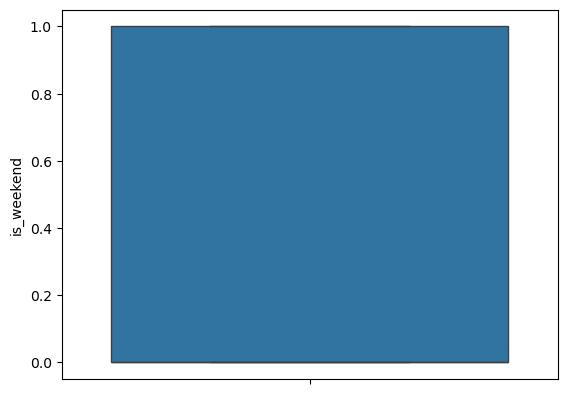

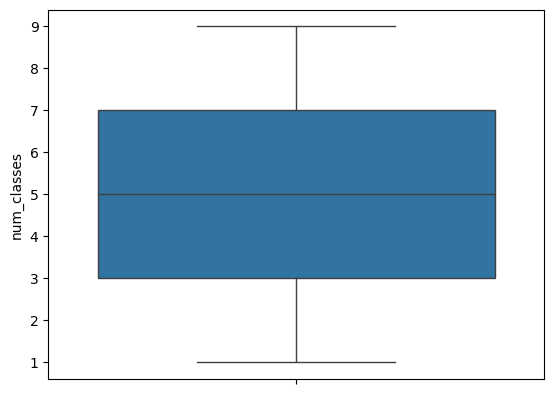

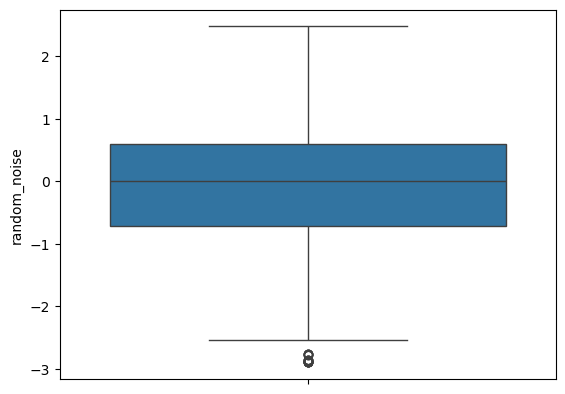

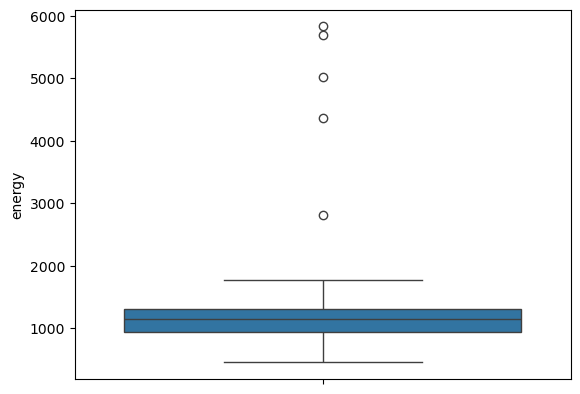

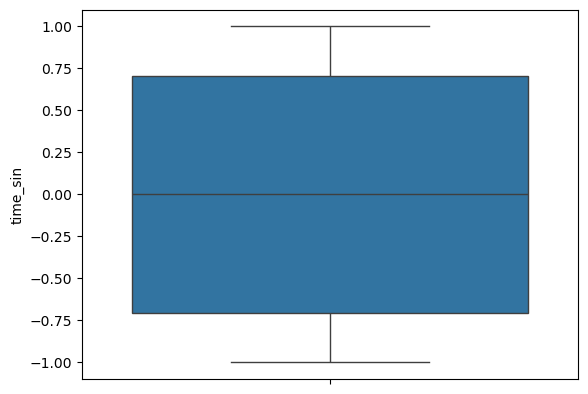

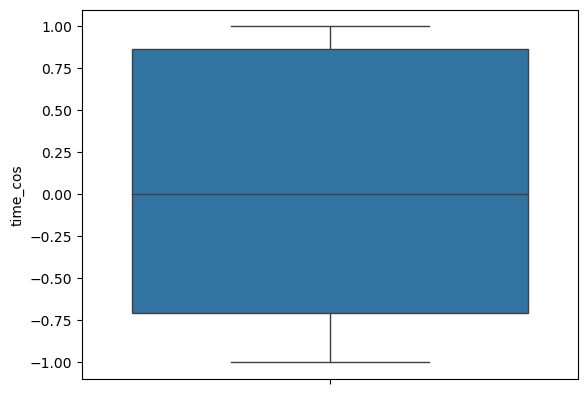

In [222]:
#Checking for outliers

for col in df:
    sns.boxplot(df[col])
    plt.show()

In [223]:
#Removing outliers

for col in df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

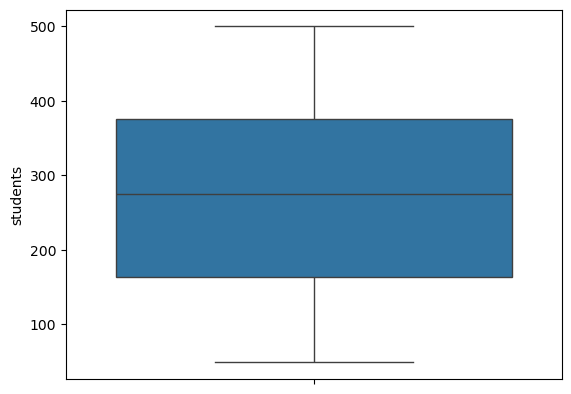

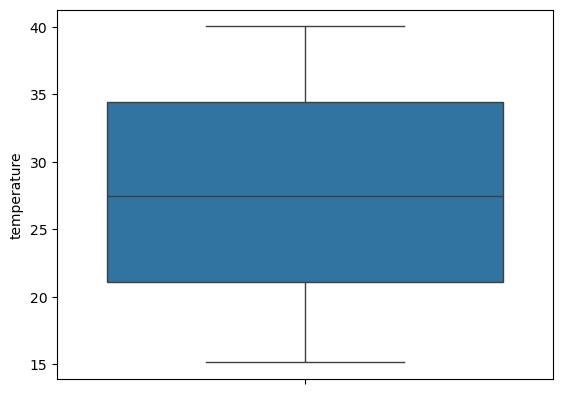

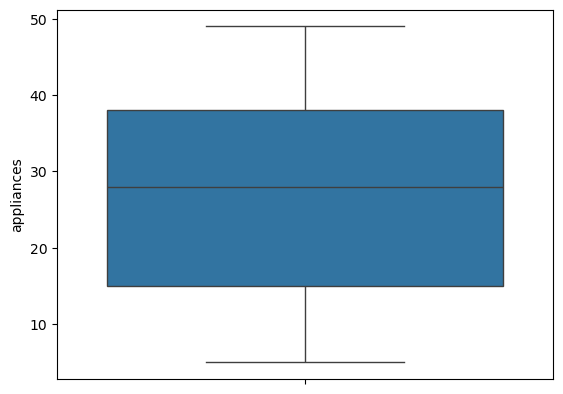

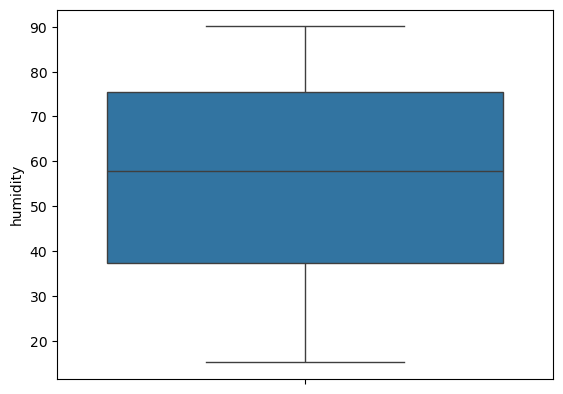

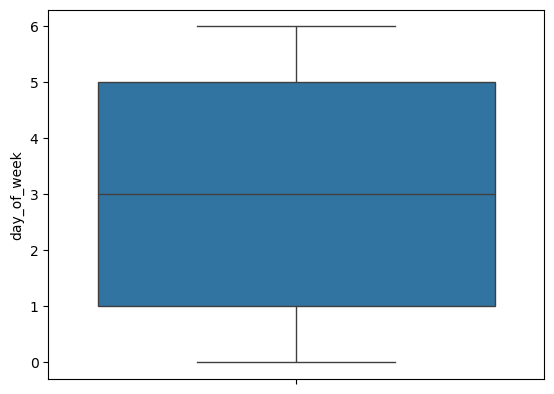

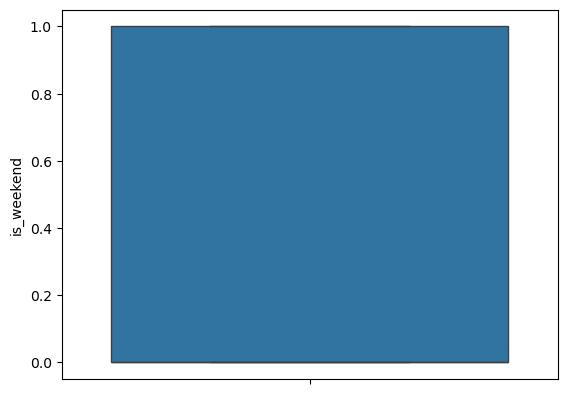

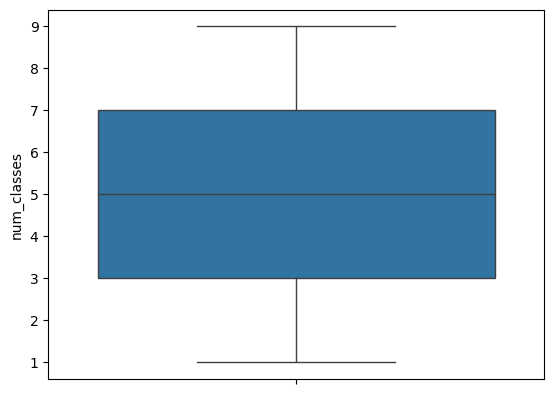

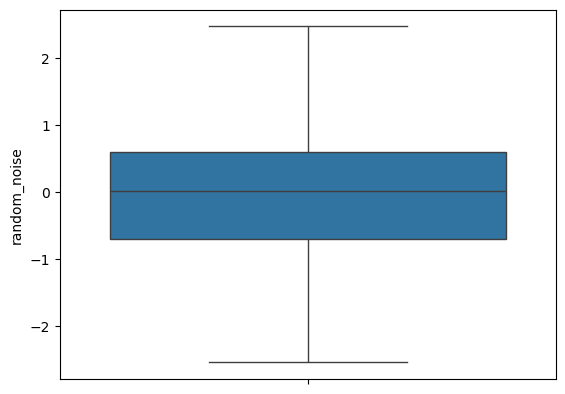

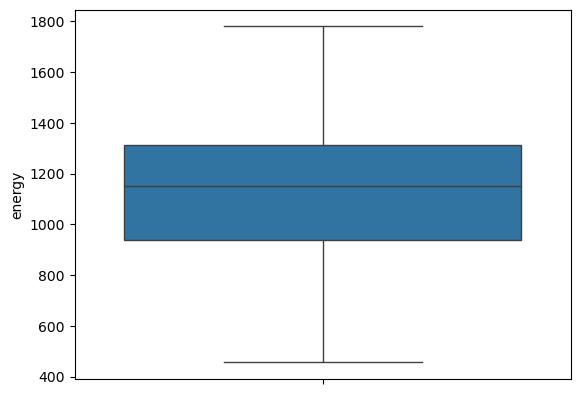

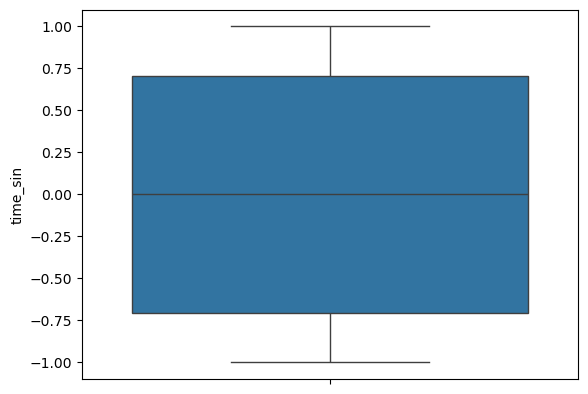

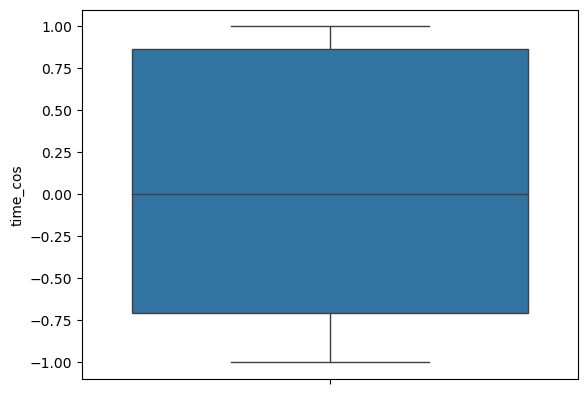

In [224]:
for col in df:
    sns.boxplot(df[col])
    plt.show()


=================CORRELATION=================

energy          1.000000
students        0.753267
appliances      0.425057
temperature     0.322064
num_classes     0.222228
humidity        0.172484
random_noise   -0.005215
time_sin       -0.044501
day_of_week    -0.067997
is_weekend     -0.096525
time_cos       -0.097861
Name: energy, dtype: float64


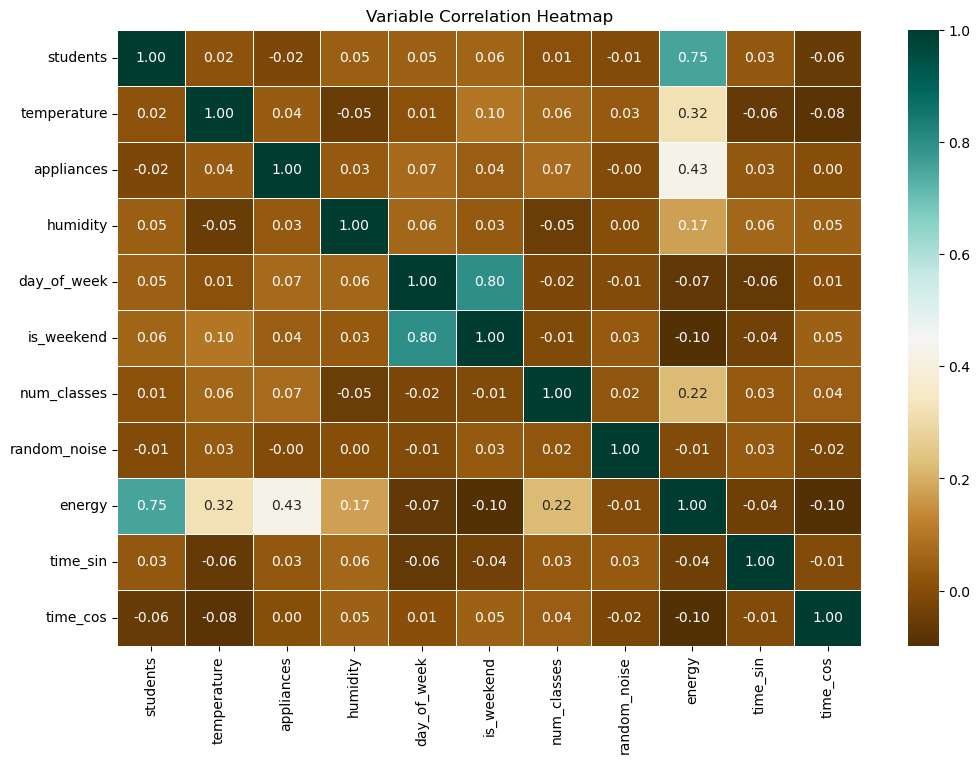

In [225]:
#Correlation analysis
correlation_matrix = df.corr(numeric_only=True)
target_corr = correlation_matrix['energy'].sort_values(ascending=False)
print("\n=================CORRELATION=================\n")
print(target_corr)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='BrBG', fmt=".2f", linewidths=0.5)
plt.title("Variable Correlation Heatmap")
plt.show()

In [226]:
#Removing highly correlated features
corr_matrix = df.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.9)]

print("\nHighly correlated features to drop:", to_drop)

df.drop(columns=to_drop, inplace=True)


Highly correlated features to drop: []


In [227]:
df.to_csv("energy1.csv", index=False)